# Context-Aware and Retrieval-Augmented Sarcasm Detection in Social Media

## Notebook 3: Context-aware transformer

This notebook trains the main model: a supervised transformer classifier using both `parent_comment` and `comment`.


In [1]:
DATASET_SLUG = "/kaggle/input/datasets/danofer/sarcasm"
INPUT_DIR = "/kaggle/input/notebooks/minatahmasebi/"
WORKING_DIR = "/kaggle/working/"
OUTPUT_DIR = "/kaggle/working/"

KAGGLE_NOTEBOOK_INPUT_NAMES = [
    "01-data-and-tfidf-baseline",
    "02-context-free-transformer",
    "03-context-aware-transformer",
    "04-retrieval-and-llm-prompts",
    "01_data_and_tfidf_baseline",
    "02_context_free_transformer",
    "03_context_aware_transformer",
    "04_retrieval_and_llm_prompts",
]

MODEL_NAME = "distilroberta-base"
RANDOM_SEED = 42

DEBUG = False
SAMPLE_SIZE = 20000

MAX_LENGTH = 256
BATCH_SIZE = 8
EPOCHS = 3
GRADIENT_ACCUMULATION_STEPS = 1

MAX_TRANSFORMER_TRAIN_ROWS = None
MAX_TRANSFORMER_EVAL_ROWS = None
CPU_MAX_TRANSFORMER_TRAIN_ROWS = 2000
CPU_MAX_TRANSFORMER_EVAL_ROWS = 500
REQUIRE_GPU_FOR_FULL_TRANSFORMER = True

RUN_TFIDF = True
RUN_CONTEXT_FREE_TRANSFORMER = True
RUN_CONTEXT_AWARE_TRANSFORMER = True
RUN_RAG = True
RUN_LLM_PROMPTS = True

MAX_RETRIEVAL_TRAIN_ROWS = 50000


## Install transformer dependencies

Kaggle often has these already. This simple cell keeps the notebook portable.


In [2]:
!pip install -q transformers accelerate


## Imports and GPU check

The model uses GPU and fp16 only when CUDA is available.


In [3]:
import gc
import inspect
import json
import os
import random
import shutil
import time
import warnings
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    set_seed,
)

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
sns.set_theme(style="whitegrid")
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
set_seed(RANDOM_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_FP16 = torch.cuda.is_available()
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("fp16 enabled:", USE_FP16)
else:
    print("No GPU detected. Training will fall back to CPU and fp16 will stay off.")


CUDA available: True
GPU: Tesla T4
fp16 enabled: True


## Shared helpers

The same metric, prediction, ZIP, and transformer helpers are reused here.


In [4]:
def kaggle_notebook_input_roots():
    input_root = Path(INPUT_DIR)
    roots = []
    if not input_root.exists():
        return roots

    for notebook_name in KAGGLE_NOTEBOOK_INPUT_NAMES:
        direct_root = input_root / notebook_name
        if direct_root.exists() and direct_root.is_dir():
            roots.append(direct_root)

        for nested_root in input_root.rglob(notebook_name):
            if nested_root.exists() and nested_root.is_dir():
                roots.append(nested_root)

    unique_roots = []
    seen = set()
    for root in roots:
        resolved = root.resolve()
        if resolved not in seen:
            seen.add(resolved)
            unique_roots.append(root)
    return unique_roots


def prepare_input_search():
    print("Kaggle input search uses this order:")
    for root in search_roots():
        status = "exists" if root.exists() else "missing"
        print(f"- {root} [{status}]")
    print("Previous notebook outputs are expected at /kaggle/input/<notebook-name>/<output-files>.")


def search_roots():
    roots = [Path(WORKING_DIR)]
    roots.extend(kaggle_notebook_input_roots())
    roots.append(Path(INPUT_DIR))

    unique_roots = []
    seen = set()
    for root in roots:
        resolved = root.resolve() if root.exists() else root
        if resolved not in seen:
            seen.add(resolved)
            unique_roots.append(root)
    return unique_roots


def find_file_recursive(filename):
    matches = []
    roots = search_roots()
    for root in roots:
        if root.exists():
            matches.extend(sorted(root.rglob(filename)))
    if not matches:
        return None

    def rank(path):
        resolved = path.resolve()
        for index, root in enumerate(roots):
            if not root.exists():
                continue
            root_resolved = root.resolve()
            if resolved == root_resolved or root_resolved in resolved.parents:
                return (index, len(str(resolved)))
        return (len(roots), len(str(resolved)))

    matches = sorted(set(matches), key=rank)
    return matches[0]


def require_file(filename, missing_message):
    path = find_file_recursive(filename)
    if path is None:
        print(missing_message)
        print("Searched these locations:")
        for root in search_roots():
            print(f"- {root}")
        raise FileNotFoundError(missing_message)
    print(f"Found {filename}: {path}")
    return path


def copy_to_working(path):
    path = Path(path)
    destination = Path(OUTPUT_DIR) / path.name
    if path.exists() and path.resolve() != destination.resolve():
        shutil.copy2(path, destination)
    return destination


def zip_outputs(zip_name, items):
    zip_path = Path(OUTPUT_DIR) / zip_name
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
        for item in items:
            path = Path(OUTPUT_DIR) / item
            if path.is_file():
                zipf.write(path, arcname=path.name)
            elif path.is_dir():
                for file_path in path.rglob("*"):
                    if file_path.is_file():
                        zipf.write(file_path, arcname=str(file_path.relative_to(Path(OUTPUT_DIR))))
            else:
                print(f"Skipping missing item: {path}")
    print(f"Created ZIP: {zip_path}")
    return zip_path



COMPARISON_COLUMNS = [
    "model_name",
    "input_type",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "macro_f1",
    "weighted_f1",
    "roc_auc",
    "average_precision",
    "test_samples",
    "positive_samples",
    "negative_samples",
    "notes",
]

METRIC_FILES = [
    "tfidf_metrics.json",
    "context_free_metrics.json",
    "context_aware_metrics.json",
]

PLOT_METRICS = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "macro_f1",
    "weighted_f1",
    "roc_auc",
    "average_precision",
]

ACADEMIC_PALETTE = [
    "#0072B2",
    "#D55E00",
    "#009E73",
    "#CC79A7",
    "#F0E442",
    "#56B4E9",
    "#E69F00",
]

METRIC_LABELS = {
    "accuracy": "Accuracy",
    "balanced_accuracy": "Balanced accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1-score",
    "macro_f1": "Macro-F1",
    "weighted_f1": "Weighted-F1",
    "roc_auc": "ROC-AUC",
    "average_precision": "Average precision",
}


def set_academic_plot_style():
    sns.set_theme(context="paper", style="whitegrid")
    plt.rcParams.update(
        {
            "font.family": "serif",
            "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
            "axes.edgecolor": "black",
            "axes.linewidth": 0.8,
            "axes.labelsize": 11,
            "axes.titlesize": 12,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "legend.fontsize": 9,
            "figure.dpi": 140,
            "savefig.dpi": 400,
            "savefig.bbox": "tight",
        }
    )


def save_figure(filename):
    path = Path(OUTPUT_DIR) / filename
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, dpi=400, bbox_inches="tight")
    pdf_path = path.with_suffix(".pdf")
    plt.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved {path}")
    print(f"Saved {pdf_path}")


def make_jsonable(value):
    if isinstance(value, dict):
        return {str(key): make_jsonable(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [make_jsonable(item) for item in value]
    if isinstance(value, np.generic):
        return make_jsonable(value.item())
    if isinstance(value, float):
        if np.isnan(value) or np.isinf(value):
            return None
        return value
    return value


def compute_model_metrics(y_true, y_pred, y_prob, model_name, input_type, notes):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    y_prob = None if y_prob is None else np.asarray(y_prob).astype(float)

    record = {
        "model_name": model_name,
        "input_type": input_type,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "roc_auc": None,
        "average_precision": None,
        "test_samples": int(len(y_true)),
        "positive_samples": int((y_true == 1).sum()),
        "negative_samples": int((y_true == 0).sum()),
        "notes": notes,
    }

    if y_prob is not None and len(np.unique(y_true)) == 2:
        try:
            record["roc_auc"] = roc_auc_score(y_true, y_prob)
        except ValueError:
            record["roc_auc"] = None
        try:
            record["average_precision"] = average_precision_score(y_true, y_prob)
        except ValueError:
            record["average_precision"] = None

    report_text = classification_report(y_true, y_pred, digits=4, zero_division=0)
    report_dict = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    record["classification_report"] = report_dict
    record["confusion_matrix"] = cm.tolist()
    return make_jsonable(record), report_text, cm


def save_confusion_matrix(y_true, y_pred, title, filename):
    set_academic_plot_style()
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5.2, 4.4))
    cmap = sns.light_palette("#0072B2", as_cmap=True)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap,
        cbar=False,
        linewidths=0.5,
        linecolor="white",
        xticklabels=["Non-sarcastic", "Sarcastic"],
        yticklabels=["Non-sarcastic", "Sarcastic"],
        ax=ax,
    )
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)
    fig.tight_layout()
    save_figure(filename)
    plt.show()


def save_model_metrics(
    y_true,
    y_pred,
    y_prob,
    model_name,
    input_type,
    notes,
    metrics_filename,
    report_filename,
    confusion_filename,
):
    record, report_text, _ = compute_model_metrics(
        y_true=y_true,
        y_pred=y_pred,
        y_prob=y_prob,
        model_name=model_name,
        input_type=input_type,
        notes=notes,
    )

    metrics_path = Path(OUTPUT_DIR) / metrics_filename
    report_path = Path(OUTPUT_DIR) / report_filename
    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(record, f, indent=2)
    report_path.write_text(report_text, encoding="utf-8")

    print(f"\n{model_name} metrics")
    for key in PLOT_METRICS:
        value = record.get(key)
        if value is None:
            print(f"{key}: NaN")
        else:
            print(f"{key}: {float(value):.4f}")

    print("\nClassification report:")
    print(report_text)
    print("Confusion matrix:")
    print(np.asarray(record["confusion_matrix"]))

    save_confusion_matrix(y_true, y_pred, model_name, confusion_filename)
    print(f"Saved metrics to {metrics_path}")
    print(f"Saved classification report to {report_path}")
    return record


def load_metric_records():
    records = []
    for filename in METRIC_FILES:
        path = find_file_recursive(filename)
        if path is None:
            continue
        with open(path, "r", encoding="utf-8") as f:
            record = json.load(f)
        records.append(record)
    return records


def _model_sort_key(name):
    name = str(name).lower()
    if "tf-idf" in name:
        return 0
    if "context-free" in name:
        return 1
    if "context-aware" in name:
        return 2
    return 3


def save_metric_plot(metrics_df, metric, filename, title):
    if metric not in metrics_df.columns:
        return
    plot_df = metrics_df.dropna(subset=[metric]).copy()
    if plot_df.empty:
        return

    set_academic_plot_style()
    plot_df = plot_df.sort_values("model_name", key=lambda series: series.map(_model_sort_key))
    colors = ACADEMIC_PALETTE[: len(plot_df)]

    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    sns.barplot(data=plot_df, x="model_name", y=metric, palette=colors, ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel(METRIC_LABELS.get(metric, metric.replace("_", " ").title()))
    ax.set_title(title)
    ax.set_ylim(0, max(1.0, float(plot_df[metric].max()) * 1.12))
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.7)
    ax.grid(axis="x", visible=False)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=18, ha="right")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)

    fig.tight_layout()
    save_figure(filename)
    plt.show()


def save_all_metrics_comparison_plot(metrics_df):
    available_metrics = [metric for metric in PLOT_METRICS if metric in metrics_df.columns and metrics_df[metric].notna().any()]
    if not available_metrics:
        return

    set_academic_plot_style()
    plot_df = metrics_df.copy()
    plot_df = plot_df.sort_values("model_name", key=lambda series: series.map(_model_sort_key))
    long_df = plot_df.melt(
        id_vars=["model_name"],
        value_vars=available_metrics,
        var_name="metric",
        value_name="score",
    ).dropna(subset=["score"])
    long_df["metric_label"] = long_df["metric"].map(METRIC_LABELS)

    fig, ax = plt.subplots(figsize=(11.5, 5.8))
    sns.barplot(
        data=long_df,
        x="metric_label",
        y="score",
        hue="model_name",
        palette=ACADEMIC_PALETTE,
        ax=ax,
    )
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.set_title("Model comparison across evaluation metrics")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.7)
    ax.grid(axis="x", visible=False)
    ax.legend(title="Model", frameon=True, loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=min(3, long_df["model_name"].nunique()))
    ax.set_xticklabels(ax.get_xticklabels(), rotation=22, ha="right")
    fig.tight_layout()
    save_figure("all_metrics_comparison.png")
    plt.show()


def update_comparison_outputs():
    records = load_metric_records()
    if not records:
        print("No metric JSON files found yet. Comparison files were not created.")
        return pd.DataFrame(columns=COMPARISON_COLUMNS)

    rows = []
    for record in records:
        row = {column: record.get(column, None) for column in COMPARISON_COLUMNS}
        rows.append(row)

    metrics_df = pd.DataFrame(rows)
    for column in COMPARISON_COLUMNS:
        if column not in metrics_df.columns:
            metrics_df[column] = np.nan
    metrics_df = metrics_df[COMPARISON_COLUMNS]
    metrics_df = metrics_df.sort_values("model_name", key=lambda series: series.map(_model_sort_key))
    metrics_df.to_csv(Path(OUTPUT_DIR) / "metrics_comparison.csv", index=False)
    print("Saved metrics_comparison.csv")
    display(metrics_df)

    save_metric_plot(metrics_df, "f1", "f1_comparison.png", "F1-score comparison")
    save_metric_plot(metrics_df, "accuracy", "accuracy_comparison.png", "Accuracy comparison")
    save_metric_plot(metrics_df, "balanced_accuracy", "balanced_accuracy_comparison.png", "Balanced accuracy comparison")
    save_metric_plot(metrics_df, "macro_f1", "macro_f1_comparison.png", "Macro-F1 comparison")

    if "roc_auc" in metrics_df.columns and metrics_df["roc_auc"].notna().any():
        save_metric_plot(metrics_df, "roc_auc", "roc_auc_comparison.png", "ROC-AUC comparison")
    if "average_precision" in metrics_df.columns and metrics_df["average_precision"].notna().any():
        save_metric_plot(metrics_df, "average_precision", "average_precision_comparison.png", "Average precision comparison")

    save_all_metrics_comparison_plot(metrics_df)
    return metrics_df



def load_prediction_file(filename):
    path = find_file_recursive(filename)
    if path is None:
        return None
    print(f"Loaded predictions from {path}")
    return pd.read_csv(path)


def attach_model_predictions(base_df, predictions_df, pred_col, prob_col):
    base_df[pred_col] = np.nan
    base_df[prob_col] = np.nan
    if predictions_df is None or pred_col not in predictions_df.columns:
        return base_df

    if "example_id" in predictions_df.columns and "example_id" in base_df.columns:
        small = predictions_df[["example_id", pred_col, prob_col]].copy()
        merged = base_df.drop(columns=[pred_col, prob_col]).merge(small, on="example_id", how="left")
        return merged

    if len(predictions_df) == len(base_df):
        base_df[pred_col] = predictions_df[pred_col].values
        if prob_col in predictions_df.columns:
            base_df[prob_col] = predictions_df[prob_col].values
    return base_df


def create_or_update_predictions_test(test_df):
    base = test_df[["example_id", "parent_comment", "comment", "label"]].copy()
    base = base.rename(columns={"label": "true_label"})

    tfidf_predictions = load_prediction_file("tfidf_predictions.csv")
    context_free_predictions = load_prediction_file("context_free_predictions.csv")
    context_aware_predictions = load_prediction_file("context_aware_predictions.csv")

    base = attach_model_predictions(base, tfidf_predictions, "tfidf_pred", "tfidf_prob")
    base = attach_model_predictions(base, context_free_predictions, "context_free_pred", "context_free_prob")
    base = attach_model_predictions(base, context_aware_predictions, "context_aware_pred", "context_aware_prob")

    output_path = Path(OUTPUT_DIR) / "predictions_test.csv"
    base.to_csv(output_path, index=False)
    print(f"Saved {output_path}")
    display(base.head())
    return base


def prediction_correctness(df, pred_col):
    if pred_col not in df.columns:
        return pd.Series(False, index=df.index)
    values = pd.to_numeric(df[pred_col], errors="coerce")
    correct = values.notna() & (values.round().astype("Int64") == df["true_label"])
    return correct.fillna(False)


def create_error_analysis(predictions_df):
    tfidf_available = predictions_df["tfidf_pred"].notna().any() if "tfidf_pred" in predictions_df.columns else False
    context_free_available = predictions_df["context_free_pred"].notna().any() if "context_free_pred" in predictions_df.columns else False
    context_aware_available = predictions_df["context_aware_pred"].notna().any() if "context_aware_pred" in predictions_df.columns else False

    tfidf_correct = prediction_correctness(predictions_df, "tfidf_pred")
    context_free_correct = prediction_correctness(predictions_df, "context_free_pred")
    context_aware_correct = prediction_correctness(predictions_df, "context_aware_pred")

    frames = []

    def add_examples(mask, model_name, pred_col, prob_col, error_type, limit=100):
        if pred_col not in predictions_df.columns:
            return
        subset = predictions_df.loc[mask & predictions_df[pred_col].notna()].head(limit).copy()
        if subset.empty:
            return
        subset["model_name"] = model_name
        subset["predicted_label"] = subset[pred_col]
        subset["probability"] = subset[prob_col] if prob_col in subset.columns else np.nan
        subset["error_type"] = error_type
        frames.append(
            subset[
                [
                    "parent_comment",
                    "comment",
                    "true_label",
                    "predicted_label",
                    "probability",
                    "model_name",
                    "error_type",
                ]
            ]
        )

    if tfidf_available and context_aware_available:
        add_examples(
            (~tfidf_correct) & context_aware_correct,
            "Context-aware Transformer",
            "context_aware_pred",
            "context_aware_prob",
            "TF-IDF wrong but context-aware transformer correct",
        )

    if context_free_available and context_aware_available:
        add_examples(
            (~context_free_correct) & context_aware_correct,
            "Context-aware Transformer",
            "context_aware_pred",
            "context_aware_prob",
            "Context-free transformer wrong but context-aware transformer correct",
        )

    if context_aware_available:
        add_examples(
            ~context_aware_correct,
            "Context-aware Transformer",
            "context_aware_pred",
            "context_aware_prob",
            "Context-aware transformer wrong",
        )

    available_correctness = []
    if tfidf_available:
        available_correctness.append(tfidf_correct)
    if context_free_available:
        available_correctness.append(context_free_correct)
    if context_aware_available:
        available_correctness.append(context_aware_correct)

    if available_correctness:
        all_correct = available_correctness[0].copy()
        all_wrong = ~available_correctness[0].copy()
        for correctness in available_correctness[1:]:
            all_correct = all_correct & correctness
            all_wrong = all_wrong & (~correctness)

        preferred_pred_col = "context_aware_pred" if context_aware_available else ("context_free_pred" if context_free_available else "tfidf_pred")
        preferred_prob_col = preferred_pred_col.replace("_pred", "_prob")
        add_examples(all_wrong, "All available models", preferred_pred_col, preferred_prob_col, "All available models wrong")
        add_examples(all_correct, "All available models", preferred_pred_col, preferred_prob_col, "All available models correct")

    if frames:
        error_analysis = pd.concat(frames, ignore_index=True)
    else:
        error_analysis = pd.DataFrame(
            columns=[
                "parent_comment",
                "comment",
                "true_label",
                "predicted_label",
                "probability",
                "model_name",
                "error_type",
            ]
        )

    output_path = Path(OUTPUT_DIR) / "error_analysis.csv"
    error_analysis.to_csv(output_path, index=False)
    print(f"Saved {output_path}")
    display(error_analysis.head(10))
    return error_analysis



def softmax(logits):
    logits = np.asarray(logits)
    logits = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(logits)
    return exp / exp.sum(axis=1, keepdims=True)


def trainer_compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = softmax(logits)[:, 1]
    preds = np.argmax(logits, axis=1)
    record, _, _ = compute_model_metrics(
        y_true=labels,
        y_pred=preds,
        y_prob=probs,
        model_name="validation",
        input_type="validation",
        notes="Validation metrics for Trainer.",
    )
    return {
        "accuracy": record["accuracy"],
        "balanced_accuracy": record["balanced_accuracy"],
        "precision": record["precision"],
        "recall": record["recall"],
        "f1": record["f1"],
        "macro_f1": record["macro_f1"],
        "weighted_f1": record["weighted_f1"],
        "roc_auc": record["roc_auc"] if record["roc_auc"] is not None else 0.0,
        "average_precision": record["average_precision"] if record["average_precision"] is not None else 0.0,
    }


def make_training_args(output_dir, run_name):
    signature = inspect.signature(TrainingArguments.__init__)
    kwargs = {
        "output_dir": str(output_dir),
        "learning_rate": 2e-5,
        "per_device_train_batch_size": BATCH_SIZE,
        "per_device_eval_batch_size": BATCH_SIZE,
        "num_train_epochs": EPOCHS,
        "weight_decay": 0.01,
        "save_strategy": "epoch",
        "load_best_model_at_end": True,
        "metric_for_best_model": "f1",
        "greater_is_better": True,
        "save_total_limit": 1,
        "logging_steps": 50,
        "report_to": [],
        "seed": RANDOM_SEED,
        "fp16": USE_FP16,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    }
    strategy_key = "eval_strategy" if "eval_strategy" in signature.parameters else "evaluation_strategy"
    kwargs[strategy_key] = "epoch"
    if "logging_strategy" in signature.parameters:
        kwargs["logging_strategy"] = "steps"
    if "run_name" in signature.parameters:
        kwargs["run_name"] = run_name
    return TrainingArguments(**kwargs)


class SarcasmDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, tokenizer, input_type):
        self.labels = dataframe["label"].astype(int).tolist()
        comments = dataframe["comment"].fillna("").astype(str).tolist()
        parents = dataframe["parent_comment"].fillna("").astype(str).tolist()

        if input_type == "context_free":
            self.encodings = tokenizer(
                comments,
                truncation=True,
                max_length=MAX_LENGTH,
            )
        elif input_type == "context_aware":
            self.encodings = tokenizer(
                text=parents,
                text_pair=comments,
                truncation=True,
                max_length=MAX_LENGTH,
            )
        else:
            raise ValueError("input_type must be context_free or context_aware")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(values[idx]) for key, values in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item



def stratified_limit_frame(frame, max_rows, name):
    if max_rows is None or len(frame) <= max_rows:
        return frame.reset_index(drop=True)

    if "label" in frame.columns and frame["label"].nunique() > 1:
        sampled, _ = train_test_split(
            frame,
            train_size=max_rows,
            stratify=frame["label"],
            random_state=RANDOM_SEED,
        )
    else:
        sampled = frame.sample(n=max_rows, random_state=RANDOM_SEED)

    sort_columns = ["example_id"] if "example_id" in sampled.columns else None
    if sort_columns is not None:
        sampled = sampled.sort_values(sort_columns)
    sampled = sampled.reset_index(drop=True)
    print(f"Limited {name} from {len(frame):,} to {len(sampled):,} rows for transformer stability.")
    return sampled



def prepare_transformer_data_for_runtime(train_frame, validation_frame, test_frame):
    global BATCH_SIZE, MAX_LENGTH, EPOCHS, MODEL_NAME

    if torch.cuda.is_available():
        train_limit = MAX_TRANSFORMER_TRAIN_ROWS
        eval_limit = MAX_TRANSFORMER_EVAL_ROWS
        if MODEL_NAME == "roberta-base":
            BATCH_SIZE = min(BATCH_SIZE, 4)
            runtime_note = "roberta-base selected; batch size capped at 4 for Kaggle GPU memory."
        else:
            runtime_note = "Using the full Kaggle GPU transformer configuration."
    else:
        if REQUIRE_GPU_FOR_FULL_TRANSFORMER and not DEBUG:
            raise RuntimeError(
                "Full transformer training requires a Kaggle GPU. Enable GPU in Notebook Settings, "
                "or set DEBUG=True for a small CPU-safe run."
            )
        train_limit = CPU_MAX_TRANSFORMER_TRAIN_ROWS
        eval_limit = CPU_MAX_TRANSFORMER_EVAL_ROWS
        BATCH_SIZE = min(BATCH_SIZE, 4)
        MAX_LENGTH = min(MAX_LENGTH, 128)
        EPOCHS = min(EPOCHS, 1)
        if MODEL_NAME == "roberta-base":
            print("No GPU detected and roberta-base is heavy. Switching to distilroberta-base for the CPU-safe run.")
            MODEL_NAME = "distilroberta-base"
        runtime_note = "CPU detected; using a small deterministic subset and lighter settings."

    print(runtime_note)
    print(f"Runtime transformer config: MODEL_NAME={MODEL_NAME}, MAX_LENGTH={MAX_LENGTH}, BATCH_SIZE={BATCH_SIZE}, EPOCHS={EPOCHS}")

    train_frame = stratified_limit_frame(train_frame, train_limit, "train")
    validation_frame = stratified_limit_frame(validation_frame, eval_limit, "validation")
    test_frame = stratified_limit_frame(test_frame, eval_limit, "test")
    return train_frame, validation_frame, test_frame


def train_transformer_model(
    input_type,
    model_label,
    model_output_dir,
    predictions_filename,
    metrics_filename,
    report_filename,
    confusion_filename,
    notes,
):
    start_time = time.time()
    model_output_dir = Path(OUTPUT_DIR) / model_output_dir
    trainer_output_dir = Path(OUTPUT_DIR) / f"{model_output_dir.name}_trainer"

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
        low_cpu_mem_usage=True,
    )
    if MODEL_NAME == "roberta-base" and hasattr(model, "gradient_checkpointing_enable"):
        model.gradient_checkpointing_enable()
        print("Gradient checkpointing enabled for roberta-base to reduce GPU memory use.")

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    train_dataset = SarcasmDataset(train_df, tokenizer, input_type)
    validation_dataset = SarcasmDataset(validation_df, tokenizer, input_type)
    test_dataset = SarcasmDataset(test_df, tokenizer, input_type)

    training_args = make_training_args(trainer_output_dir, run_name=model_output_dir.name)

    trainer_kwargs = {
        "model": model,
        "args": training_args,
        "train_dataset": train_dataset,
        "eval_dataset": validation_dataset,
        "compute_metrics": trainer_compute_metrics,
        "callbacks": [EarlyStoppingCallback(early_stopping_patience=1)],
        "data_collator": data_collator,
    }
    trainer_signature = inspect.signature(Trainer.__init__)
    if "processing_class" in trainer_signature.parameters:
        trainer_kwargs["processing_class"] = tokenizer
    elif "tokenizer" in trainer_signature.parameters:
        trainer_kwargs["tokenizer"] = tokenizer

    trainer = Trainer(**trainer_kwargs)

    trainer.train()
    trainer.save_model(model_output_dir)
    tokenizer.save_pretrained(model_output_dir)

    prediction_output = trainer.predict(test_dataset)
    probs = softmax(prediction_output.predictions)[:, 1]
    preds = (probs >= 0.5).astype(int)

    training_time_minutes = (time.time() - start_time) / 60
    full_notes = f"{notes} Training time: {training_time_minutes:.2f} minutes."

    metrics_record = save_model_metrics(
        y_true=test_df["label"],
        y_pred=preds,
        y_prob=probs,
        model_name=model_label,
        input_type="comment" if input_type == "context_free" else "parent_comment + comment",
        notes=full_notes,
        metrics_filename=metrics_filename,
        report_filename=report_filename,
        confusion_filename=confusion_filename,
    )

    predictions = test_df[["example_id", "parent_comment", "comment", "label"]].copy()
    predictions = predictions.rename(columns={"label": "true_label"})
    prefix = "context_free" if input_type == "context_free" else "context_aware"
    predictions[f"{prefix}_pred"] = preds
    predictions[f"{prefix}_prob"] = probs
    predictions.to_csv(Path(OUTPUT_DIR) / predictions_filename, index=False)
    print(f"Saved {predictions_filename}")
    print(f"Saved model to {model_output_dir}")

    update_comparison_outputs()

    del trainer, model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return predictions, metrics_record


## Load previous outputs

The notebook searches `/kaggle/working/` and Kaggle notebook-output folders such as `/kaggle/input/01-data-and-tfidf-baseline/` and `/kaggle/input/02-context-free-transformer/`.


Kaggle input search uses this order:
- /kaggle/working [exists]
- /kaggle/input/notebooks/minatahmasebi/01-data-and-tfidf-baseline [exists]
- /kaggle/input/notebooks/minatahmasebi/02-context-free-transformer [exists]
- /kaggle/input/notebooks/minatahmasebi [exists]
Previous notebook outputs are expected at /kaggle/input/<notebook-name>/<output-files>.
Found train_split.csv: /kaggle/input/notebooks/minatahmasebi/01-data-and-tfidf-baseline/train_split.csv
Found validation_split.csv: /kaggle/input/notebooks/minatahmasebi/01-data-and-tfidf-baseline/validation_split.csv
Found test_split.csv: /kaggle/input/notebooks/minatahmasebi/01-data-and-tfidf-baseline/test_split.csv
Train shape before transformer limits: (706978, 5)
Validation shape before transformer limits: (151495, 5)
Test shape before transformer limits: (151496, 5)
Using the full Kaggle GPU transformer configuration.
Runtime transformer config: MODEL_NAME=distilroberta-base, MAX_LENGTH=256, BATCH_SIZE=8, EPOCHS=3
Train shape used b

,example_id,parent_comment,comment,label,subreddit
0,516895,About the new battery changes I would like to ...,This is so that torpedoes don't have to waste ...,0,spaceengineers
1,313186,Remain's Ageism Following the Brexit EU Refere...,Old people = literally Hitler.,1,ukpolitics
2,595104,What do you regret not doing as a horny teenager?,Basically doing anything with a girl.,0,AskReddit


Saved metrics_comparison.csv


,model_name,input_type,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,average_precision,test_samples,positive_samples,negative_samples,notes
0,TF-IDF + Logistic Regression,comment,0.722012,0.722018,0.739224,0.686163,0.711706,0.721657,0.721655,0.794790,0.801186,151496,75759,75737,Context-free TF-IDF baseline using comment onl...
1,Context-free Transformer (distilroberta-base),comment,0.772476,0.772471,0.756894,0.802901,0.779219,0.772263,0.772264,0.858547,0.866250,151496,75759,75737,Transformer fine-tuned only on the target repl...


Saved /kaggle/working/f1_comparison.png
Saved /kaggle/working/f1_comparison.pdf


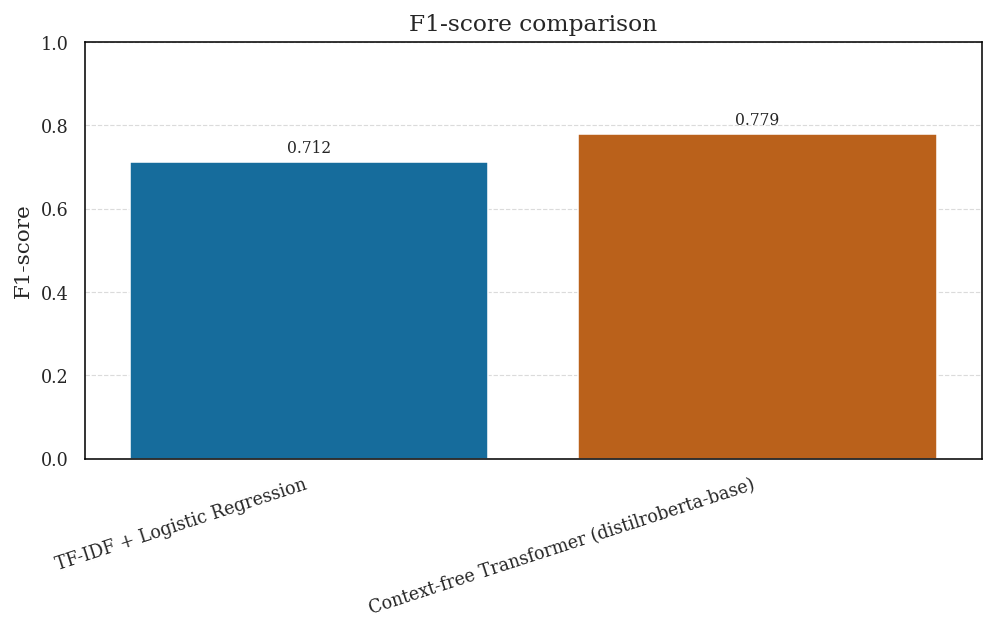

Saved /kaggle/working/accuracy_comparison.png
Saved /kaggle/working/accuracy_comparison.pdf


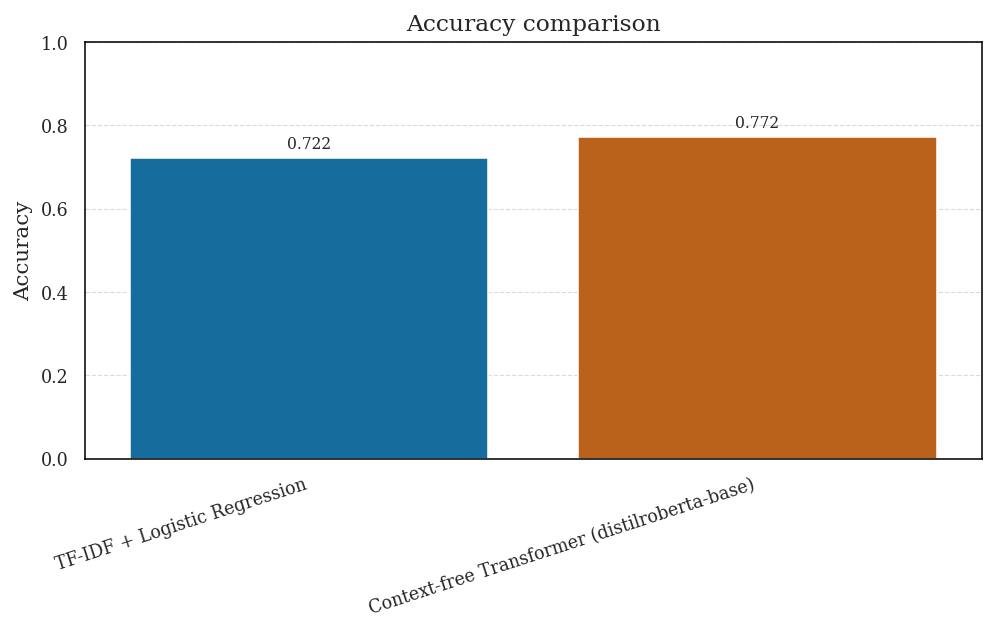

Saved /kaggle/working/balanced_accuracy_comparison.png
Saved /kaggle/working/balanced_accuracy_comparison.pdf


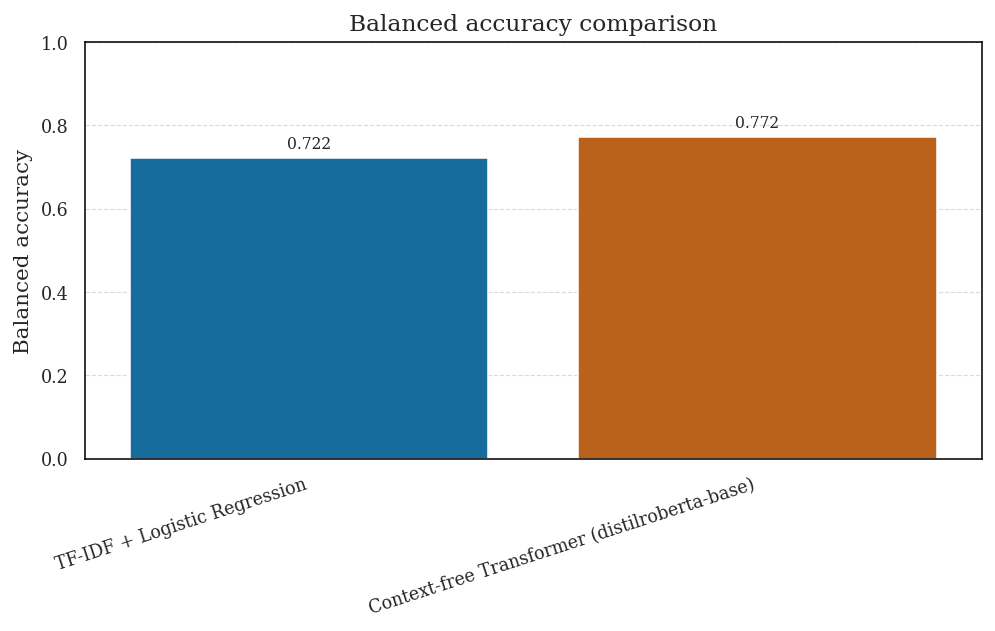

Saved /kaggle/working/macro_f1_comparison.png
Saved /kaggle/working/macro_f1_comparison.pdf


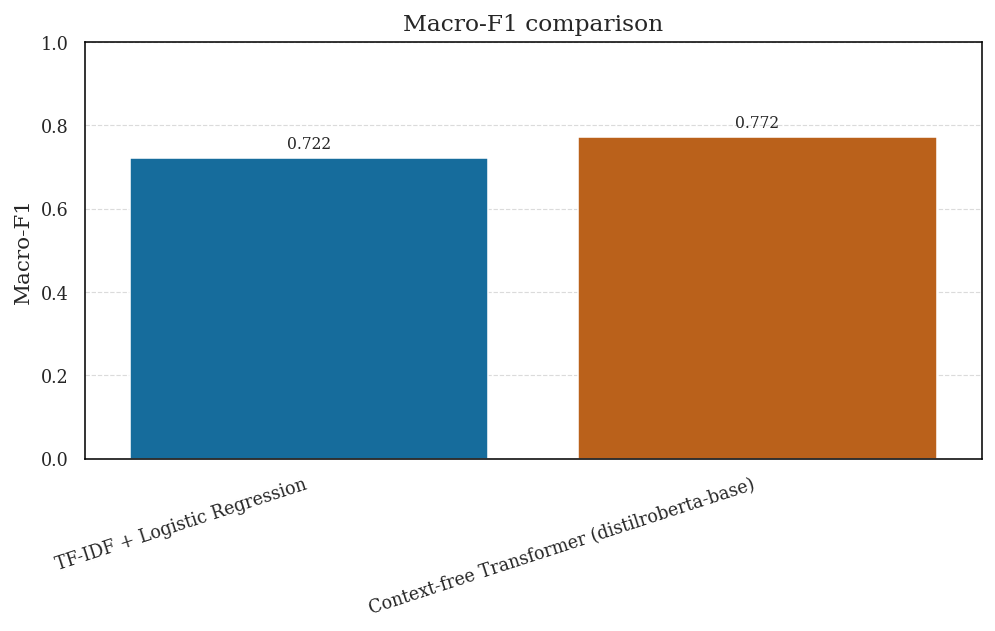

Saved /kaggle/working/roc_auc_comparison.png
Saved /kaggle/working/roc_auc_comparison.pdf


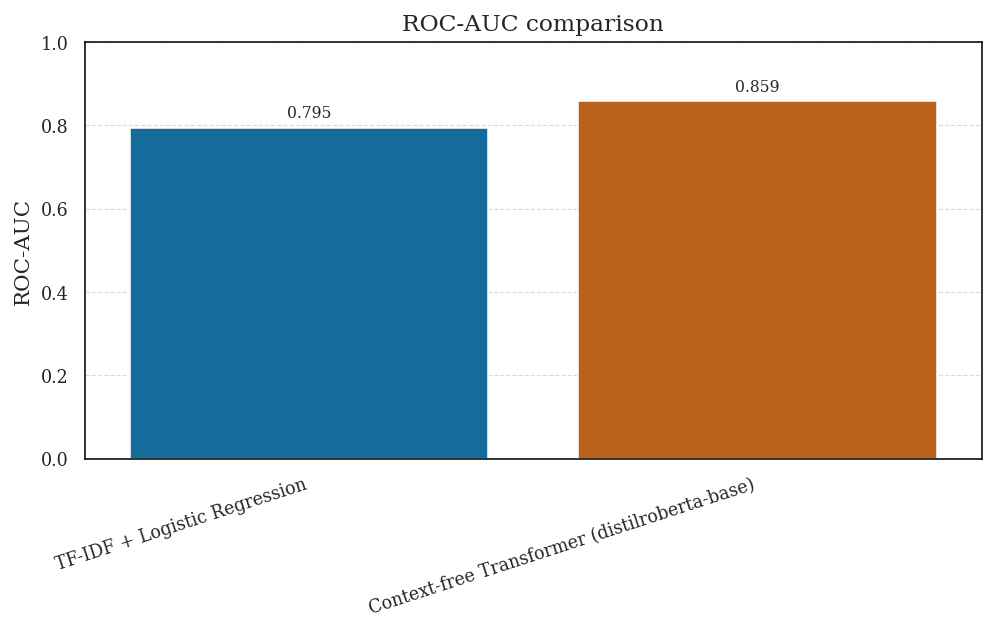

Saved /kaggle/working/average_precision_comparison.png
Saved /kaggle/working/average_precision_comparison.pdf


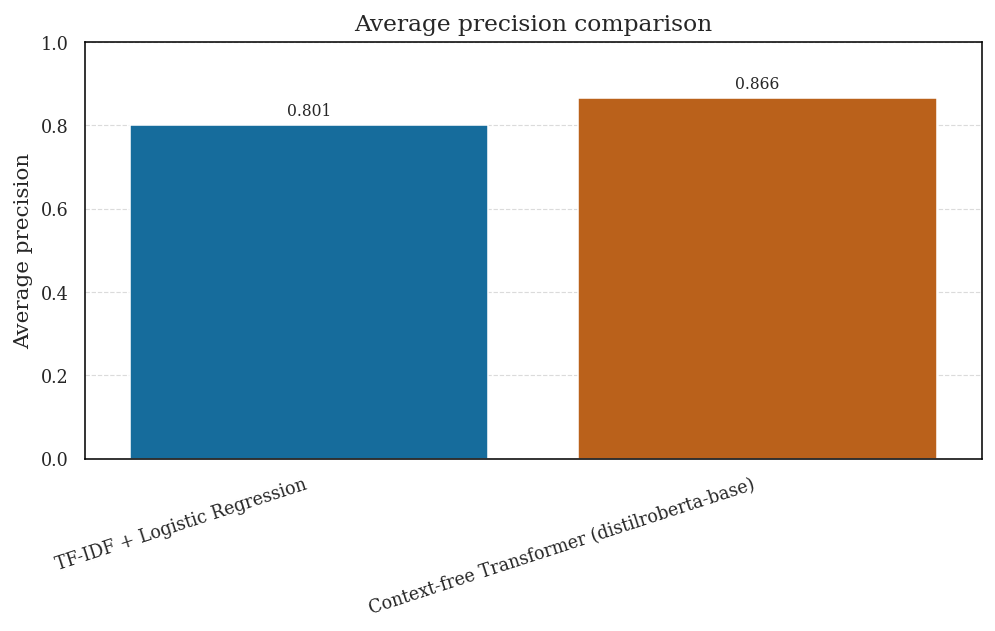

Saved /kaggle/working/all_metrics_comparison.png
Saved /kaggle/working/all_metrics_comparison.pdf


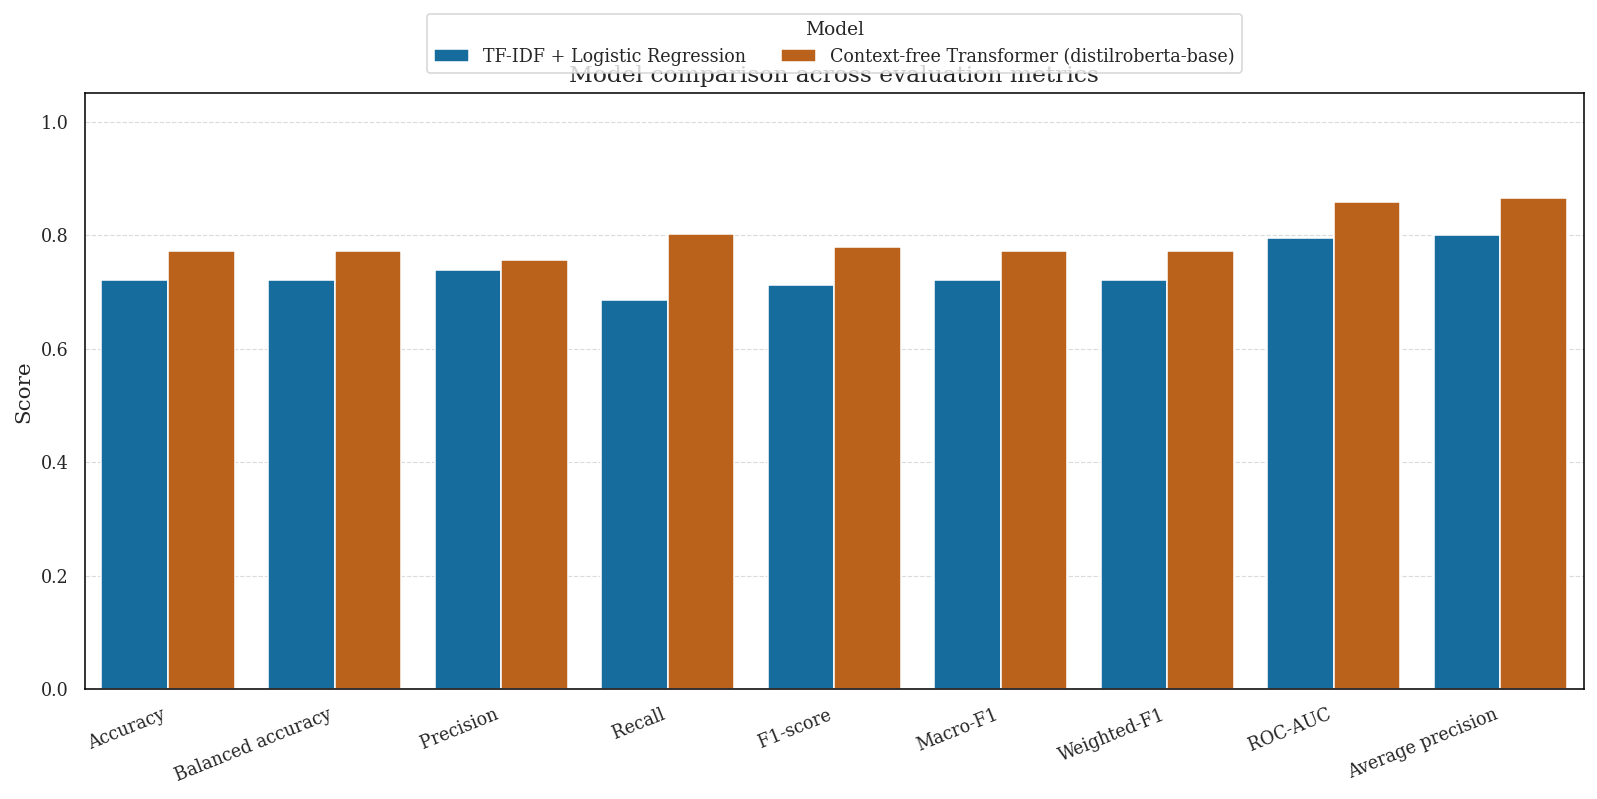

,model_name,input_type,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,average_precision,test_samples,positive_samples,negative_samples,notes
0,TF-IDF + Logistic Regression,comment,0.722012,0.722018,0.739224,0.686163,0.711706,0.721657,0.721655,0.794790,0.801186,151496,75759,75737,Context-free TF-IDF baseline using comment onl...
1,Context-free Transformer (distilroberta-base),comment,0.772476,0.772471,0.756894,0.802901,0.779219,0.772263,0.772264,0.858547,0.866250,151496,75759,75737,Transformer fine-tuned only on the target repl...


In [5]:
prepare_input_search()

train_path = require_file(
    "train_split.csv",
    "Missing train_split.csv. Please run Notebook 1 first or attach Notebook 1 outputs as a Kaggle dataset.",
)
validation_path = require_file(
    "validation_split.csv",
    "Missing validation_split.csv. Please run Notebook 1 first or attach Notebook 1 outputs as a Kaggle dataset.",
)
test_path = require_file(
    "test_split.csv",
    "Missing test_split.csv. Please run Notebook 1 first or attach Notebook 1 outputs as a Kaggle dataset.",
)

train_df = pd.read_csv(train_path)
validation_df = pd.read_csv(validation_path)
test_df = pd.read_csv(test_path)

for frame in [train_df, validation_df, test_df]:
    if "example_id" not in frame.columns:
        frame["example_id"] = np.arange(len(frame))

print("Train shape before transformer limits:", train_df.shape)
print("Validation shape before transformer limits:", validation_df.shape)
print("Test shape before transformer limits:", test_df.shape)
train_df, validation_df, test_df = prepare_transformer_data_for_runtime(train_df, validation_df, test_df)
print("Train shape used by transformer:", train_df.shape)
print("Validation shape used by transformer:", validation_df.shape)
print("Test shape used by transformer:", test_df.shape)
display(train_df.head(3))
update_comparison_outputs()


## Train context-aware transformer

This is the selected approach. The tokenizer receives the parent comment as the first text and the reply as the paired text.


config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Context-aware Transformer (distilroberta-base) metrics
accuracy: 0.7824
balanced_accuracy: 0.7824
precision: 0.7648
recall: 0.8159
f1: 0.7895
macro_f1: 0.7822
weighted_f1: 0.7822
roc_auc: 0.8694
average_precision: 0.8753

Classification report:
              precision    recall  f1-score   support

           0     0.8027    0.7490    0.7749     75737
           1     0.7648    0.8159    0.7895     75759

    accuracy                         0.7824    151496
   macro avg     0.7837    0.7824    0.7822    151496
weighted avg     0.7837    0.7824    0.7822    151496

Confusion matrix:
[[56724 19013]
 [13946 61813]]
Saved /kaggle/working/confusion_matrix_context_aware.png
Saved /kaggle/working/confusion_matrix_context_aware.pdf


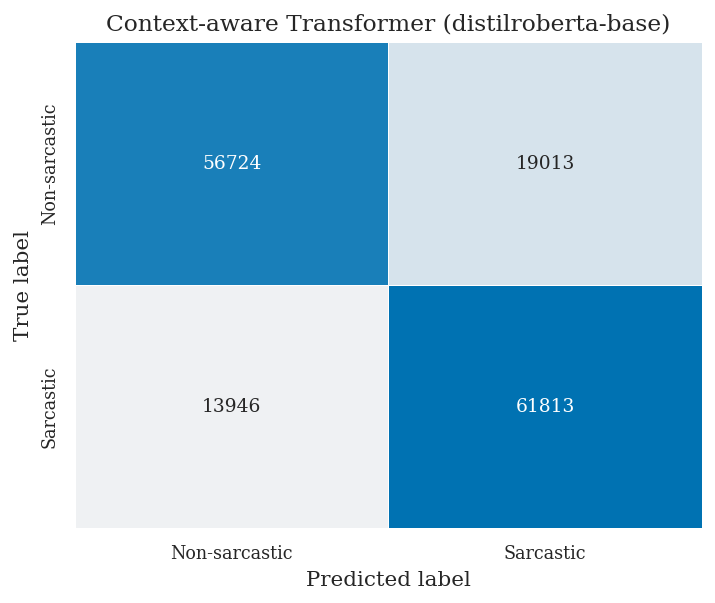

Saved metrics to /kaggle/working/context_aware_metrics.json
Saved classification report to /kaggle/working/context_aware_classification_report.txt
Saved context_aware_predictions.csv
Saved model to /kaggle/working/context_aware_model
Saved metrics_comparison.csv


,model_name,input_type,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,average_precision,test_samples,positive_samples,negative_samples,notes
0,TF-IDF + Logistic Regression,comment,0.722012,0.722018,0.739224,0.686163,0.711706,0.721657,0.721655,0.794790,0.801186,151496,75759,75737,Context-free TF-IDF baseline using comment onl...
1,Context-free Transformer (distilroberta-base),comment,0.772476,0.772471,0.756894,0.802901,0.779219,0.772263,0.772264,0.858547,0.866250,151496,75759,75737,Transformer fine-tuned only on the target repl...
2,Context-aware Transformer (distilroberta-base),parent_comment + comment,0.782443,0.782438,0.764766,0.815916,0.789514,0.782197,0.782198,0.869390,0.875310,151496,75759,75737,Main model: transformer fine-tuned on parent_c...


Saved /kaggle/working/f1_comparison.png
Saved /kaggle/working/f1_comparison.pdf


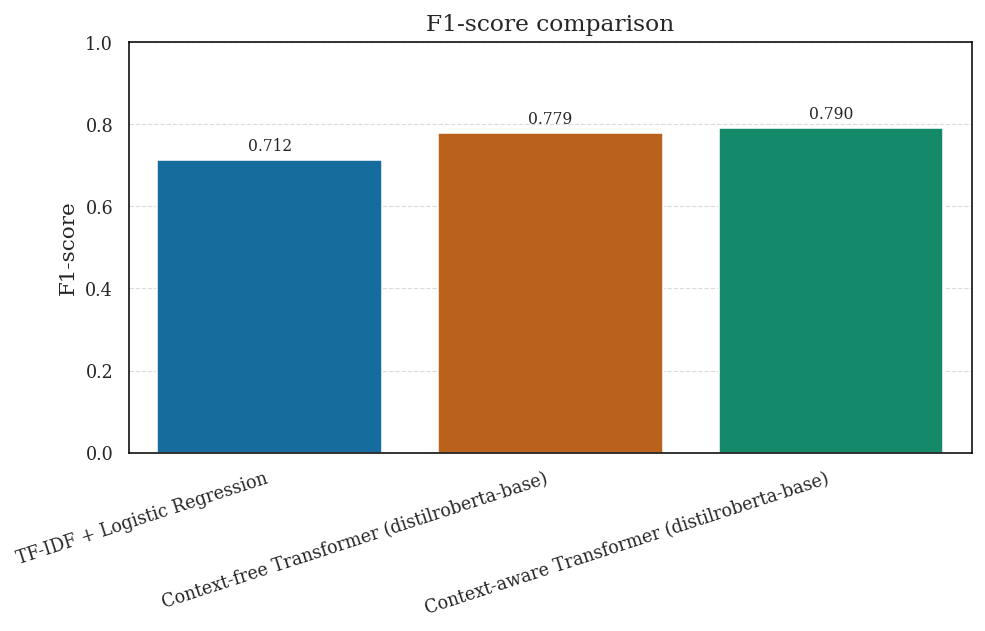

Saved /kaggle/working/accuracy_comparison.png
Saved /kaggle/working/accuracy_comparison.pdf


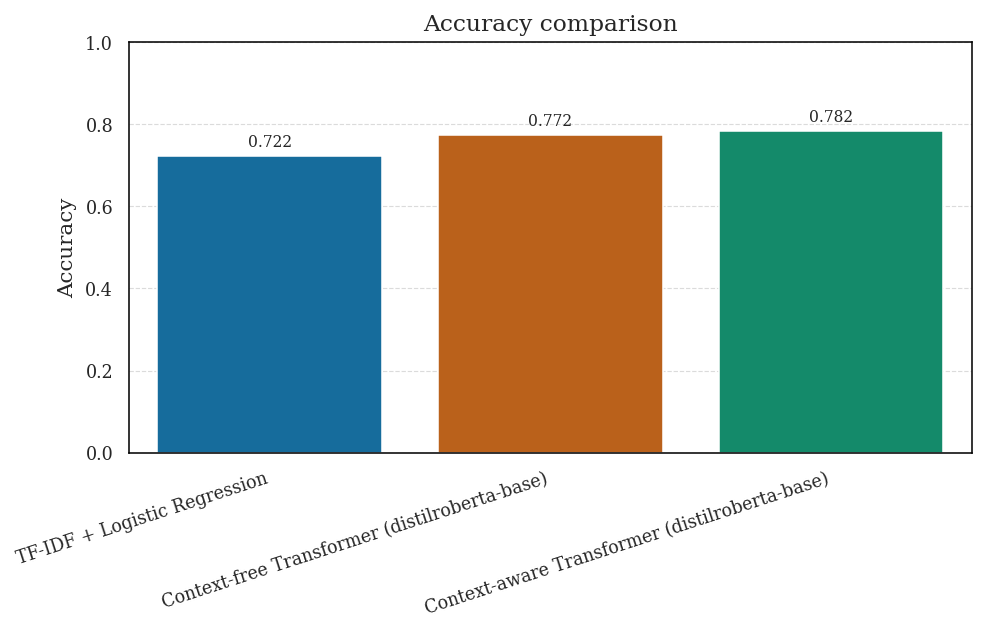

Saved /kaggle/working/balanced_accuracy_comparison.png
Saved /kaggle/working/balanced_accuracy_comparison.pdf


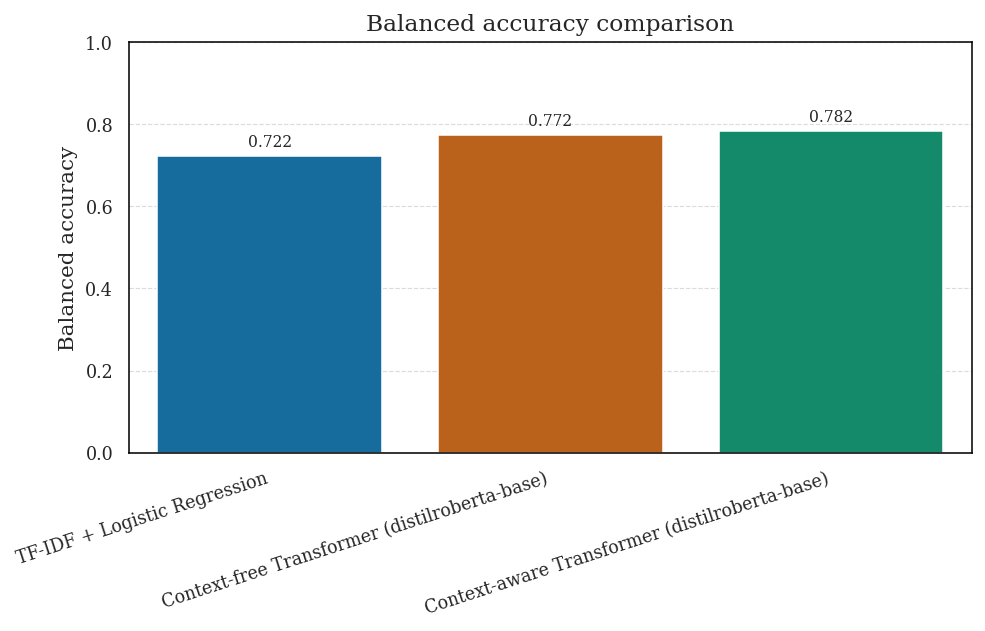

Saved /kaggle/working/macro_f1_comparison.png
Saved /kaggle/working/macro_f1_comparison.pdf


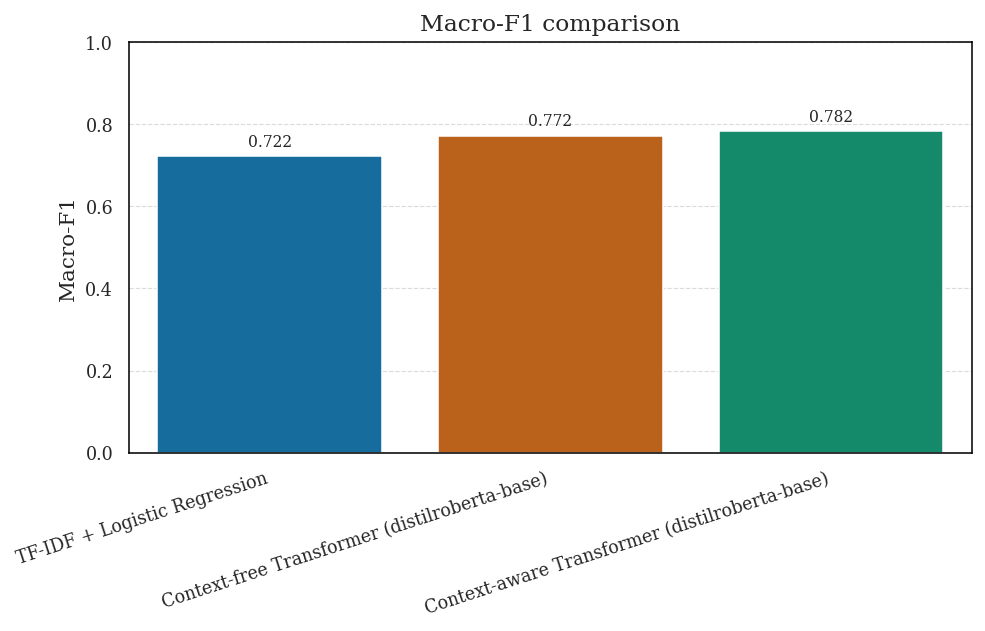

Saved /kaggle/working/roc_auc_comparison.png
Saved /kaggle/working/roc_auc_comparison.pdf


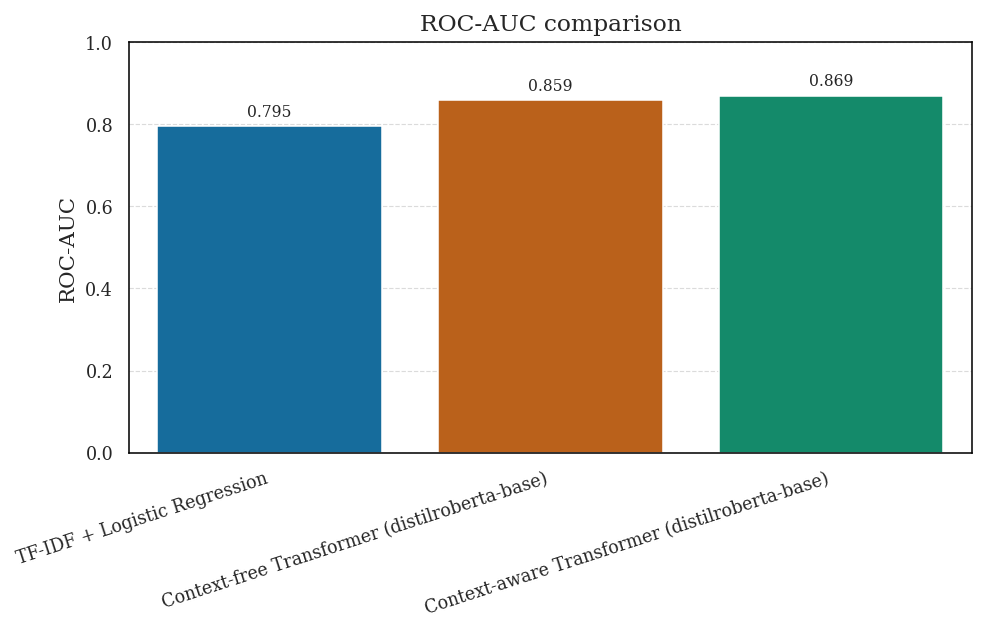

Saved /kaggle/working/average_precision_comparison.png
Saved /kaggle/working/average_precision_comparison.pdf


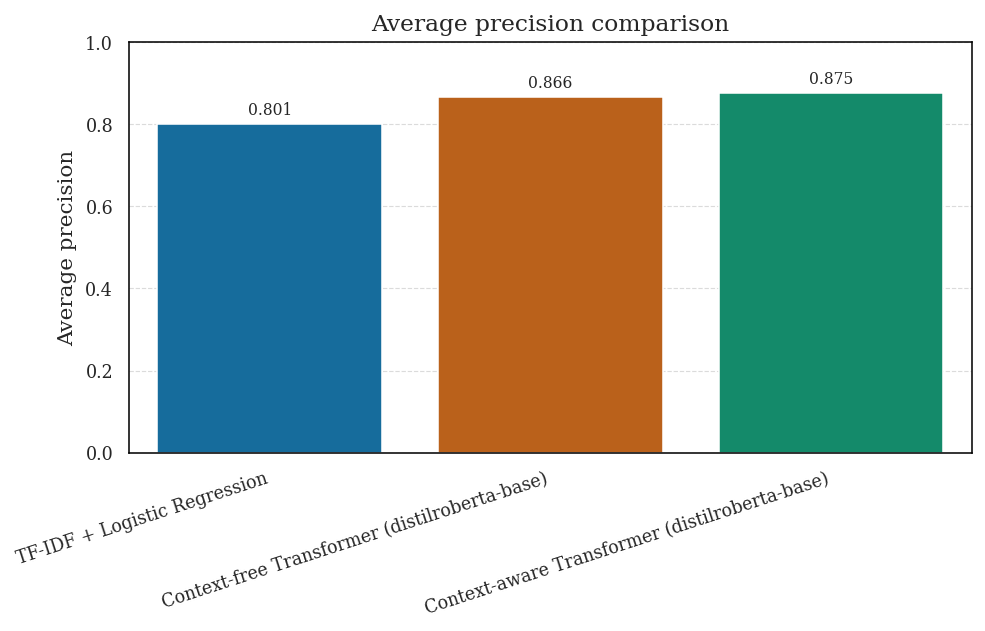

Saved /kaggle/working/all_metrics_comparison.png
Saved /kaggle/working/all_metrics_comparison.pdf


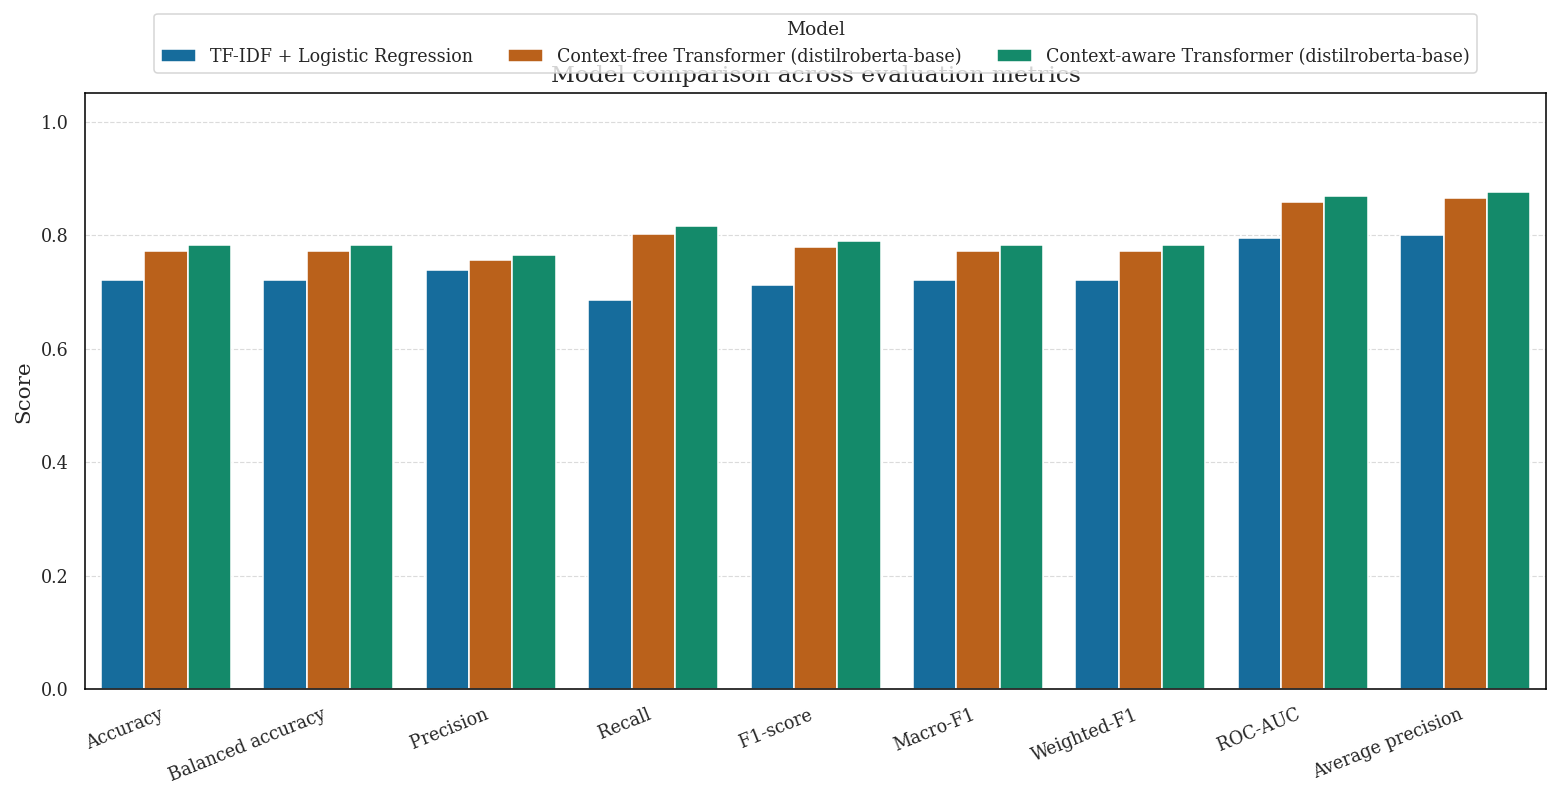

In [6]:
if RUN_CONTEXT_AWARE_TRANSFORMER:
    context_aware_predictions, context_aware_metrics = train_transformer_model(
        input_type="context_aware",
        model_label=f"Context-aware Transformer ({MODEL_NAME})",
        model_output_dir="context_aware_model",
        predictions_filename="context_aware_predictions.csv",
        metrics_filename="context_aware_metrics.json",
        report_filename="context_aware_classification_report.txt",
        confusion_filename="confusion_matrix_context_aware.png",
        notes="Main model: transformer fine-tuned on parent_comment plus target reply.",
    )
else:
    print("RUN_CONTEXT_AWARE_TRANSFORMER is False, so training was skipped.")
    update_comparison_outputs()


## Combined predictions and error analysis

The combined prediction file keeps missing model outputs as NaN, so it is safe to create even when one model was skipped.


In [7]:
predictions_test = create_or_update_predictions_test(test_df)
error_analysis = create_error_analysis(predictions_test)

for _, row in error_analysis.head(5).iterrows():
    print("\n---")
    print("Error type:", row["error_type"])
    print("Parent:", str(row["parent_comment"])[:350])
    print("Reply:", str(row["comment"])[:350])
    print("True label:", row["true_label"], "Predicted:", row["predicted_label"], "Probability:", row["probability"])


Loaded predictions from /kaggle/input/notebooks/minatahmasebi/01-data-and-tfidf-baseline/tfidf_predictions.csv
Loaded predictions from /kaggle/input/notebooks/minatahmasebi/02-context-free-transformer/context_free_predictions.csv
Loaded predictions from /kaggle/working/context_aware_predictions.csv
Saved /kaggle/working/predictions_test.csv


,example_id,parent_comment,comment,true_label,tfidf_pred,tfidf_prob,context_free_pred,context_free_prob,context_aware_pred,context_aware_prob
0,544256,american OP gets shut down,murrica!,0,1,0.527993,1,0.691347,1,0.776398
1,129912,"10, The words ""Southern Strategy""",You are now banned from r/conservative,0,0,0.411966,1,0.772754,1,0.600449
2,507774,Space for two tails.,I like this kind of twin tails.,0,0,0.335020,0,0.097633,0,0.112222
3,349024,I can't imagine it would be too terribly diffi...,Implementing johto via liquid crystal wouldn't...,0,0,0.191774,0,0.107270,0,0.065265
4,967673,"My favorite Lucille Bluth face (S1E12), what's...",This is the reason why Jessica Walter is my fa...,0,0,0.142500,0,0.166931,0,0.160900


Saved /kaggle/working/error_analysis.csv


,parent_comment,comment,true_label,predicted_label,probability,model_name,error_type
0,Glorious Upgrade,Why do you think I had to get a new motherboard,1,1,0.915426,Context-aware Transformer,TF-IDF wrong but context-aware transformer cor...
1,Looks fucking delicious from where I stand.,"Mmm, gourmet.",1,1,0.797352,Context-aware Transformer,TF-IDF wrong but context-aware transformer cor...
2,"Thanks for nothing, assholes.",I hope the owner paid the employees a living w...,1,1,0.939335,Context-aware Transformer,TF-IDF wrong but context-aware transformer cor...
3,"Correction: He literally gets Divine Ki, big d...",i hope the guy you replied to forgot his,1,1,0.995374,Context-aware Transformer,TF-IDF wrong but context-aware transformer cor...
4,Not a supporter but what makes him fascist? Th...,For someone who hasn't held public office for ...,1,1,0.876514,Context-aware Transformer,TF-IDF wrong but context-aware transformer cor...
5,If there was a million dollar prize given to w...,I'm going to pick someone in this thread to sh...,0,0,0.189218,Context-aware Transformer,TF-IDF wrong but context-aware transformer cor...
6,TIL a Baltimore man in 1928 built a rocket in ...,Sounds like a whole lot of math went into this...,1,1,0.958938,Context-aware Transformer,TF-IDF wrong but context-aware transformer cor...
7,Just saw the new Jurassic World movie,Avengers AoU definitely had zero Audi product ...,1,1,0.955053,Context-aware Transformer,TF-IDF wrong but context-aware transformer cor...
8,Great news - but can someone please tell me wh...,Irish,0,0,0.157543,Context-aware Transformer,TF-IDF wrong but context-aware transformer cor...
9,I'm excited to watch them play the celtics thi...,Nothing is more exciting than Vanilla Ice at h...,1,1,0.786911,Context-aware Transformer,TF-IDF wrong but context-aware transformer cor...



---
Error type: TF-IDF wrong but context-aware transformer correct
Parent: Glorious Upgrade
Reply: Why do you think I had to get a new motherboard
True label: 1 Predicted: 1 Probability: 0.91542554

---
Error type: TF-IDF wrong but context-aware transformer correct
Parent: Looks fucking delicious from where I stand.
Reply: Mmm, gourmet.
True label: 1 Predicted: 1 Probability: 0.7973518

---
Error type: TF-IDF wrong but context-aware transformer correct
Parent: Thanks for nothing, assholes.
Reply: I hope the owner paid the employees a living wage and gave them 2 years salary as a bonus before he fired them!
True label: 1 Predicted: 1 Probability: 0.939335

---
Error type: TF-IDF wrong but context-aware transformer correct
Parent: Correction: He literally gets Divine Ki, big difference.
Reply: i hope the guy you replied to forgot his
True label: 1 Predicted: 1 Probability: 0.9953738

---
Error type: TF-IDF wrong but context-aware transformer correct
Parent: Not a supporter but what make

## Save Notebook 3 outputs

This ZIP is the clean handoff to the retrieval and prompt notebook.


In [8]:
context_aware_outputs = [
    "context_aware_model",
    "context_aware_metrics.json",
    "context_aware_predictions.csv",
    "context_aware_classification_report.txt",
    "predictions_test.csv",
    "metrics_comparison.csv",
    "error_analysis.csv",
    "confusion_matrix_context_aware.png",
    "confusion_matrix_context_aware.pdf",
    "f1_comparison.png",
    "accuracy_comparison.png",
    "balanced_accuracy_comparison.png",
    "macro_f1_comparison.png",
    "roc_auc_comparison.png",
    "average_precision_comparison.png",
    "f1_comparison.pdf",
    "accuracy_comparison.pdf",
    "balanced_accuracy_comparison.pdf",
    "macro_f1_comparison.pdf",
    "roc_auc_comparison.pdf",
    "average_precision_comparison.pdf",
    "all_metrics_comparison.png",
    "all_metrics_comparison.pdf",
]

zip_outputs("sarcasm_context_aware_outputs.zip", context_aware_outputs)
print("Notebook 3 complete. Next: run 04_retrieval_and_llm_prompts.ipynb.")


Created ZIP: /kaggle/working/sarcasm_context_aware_outputs.zip
Notebook 3 complete. Next: run 04_retrieval_and_llm_prompts.ipynb.
